
# 🏷️ Confusion Matrix

Aquest notebook mostra les diferents mètriques que podem extreure de la **matriu de confusió**.

---

## 🎯 Objectius
-

### 1. Importem llibreries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_curve, auc, precision_recall_curve
)




### 2. Generació d'un dataset de clasificació

In [ ]:
# el paràmetre weights=[w0, w1] determina la proporció de cada classe target
# w0 = proporció d'exemples de la classe 0
# w1 = proporció d'exemples de la classe 1

X, y = make_classification(
    n_samples=1500,
    n_features=4,
    weights=[0.2, 0.8],   # dataset desequilibrat (80%-20%)
    random_state=42
)



df = pd.DataFrame(X, columns=["carac1", "carac2", "carac3", "carac4"])
df["target"] = y

df.head()

,carac1,carac2,carac3,carac4,target
0,1.195452,-0.378485,1.179900,0.414717,1
1,1.523440,-0.060884,-0.029564,0.985944,1
2,-1.452579,0.027715,0.138553,-0.973012,0
3,-1.375768,-0.042934,0.382914,-0.996654,1
4,-0.439357,0.378806,-1.305670,0.107762,0


### 3. Separació train / test


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


### 4. Entrenem el model - Regressió Logística

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


### 5. Matriu de confusió

In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[ 73,  19],
       [  9, 349]])

In [ ]:

cm_pd = pd.crosstab(
    y_test.ravel(),
    y_pred,
    rownames=['Real'],
    colnames=['Predicción']
)
cm_pd

Predicción,0,1
Real,,
0,73,19
1,9,349


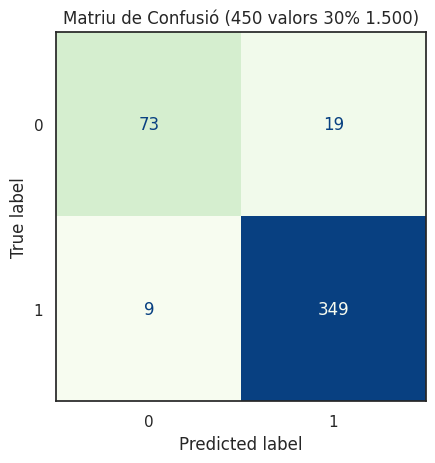

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
sns.set_theme(context = 'notebook', style = "white", font_scale = 1.0)
# Matriu de confusió amb ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    normalize = None,
    cmap="GnBu",
    colorbar=False
)

plt.title("Matriu de Confusió (450 valors 30% 1.500)")
plt.show()


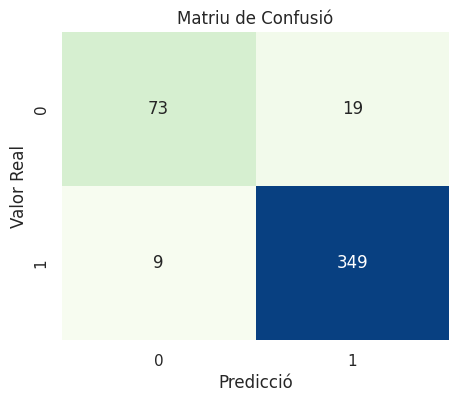

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="GnBu", cbar=False)
plt.title("Matriu de Confusió")
plt.xlabel("Predicció")
plt.ylabel("Valor Real")
plt.show()


### 6. Càlcul de totes les mètriques

In [ ]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("ACCURACY :", acc)
print("PRECISION:", prec)
print("RECALL   :", rec)
print("F1-SCORE :", f1)


ACCURACY : 0.9377777777777778
PRECISION: 0.9483695652173914
RECALL   : 0.9748603351955307
F1-SCORE : 0.9614325068870524


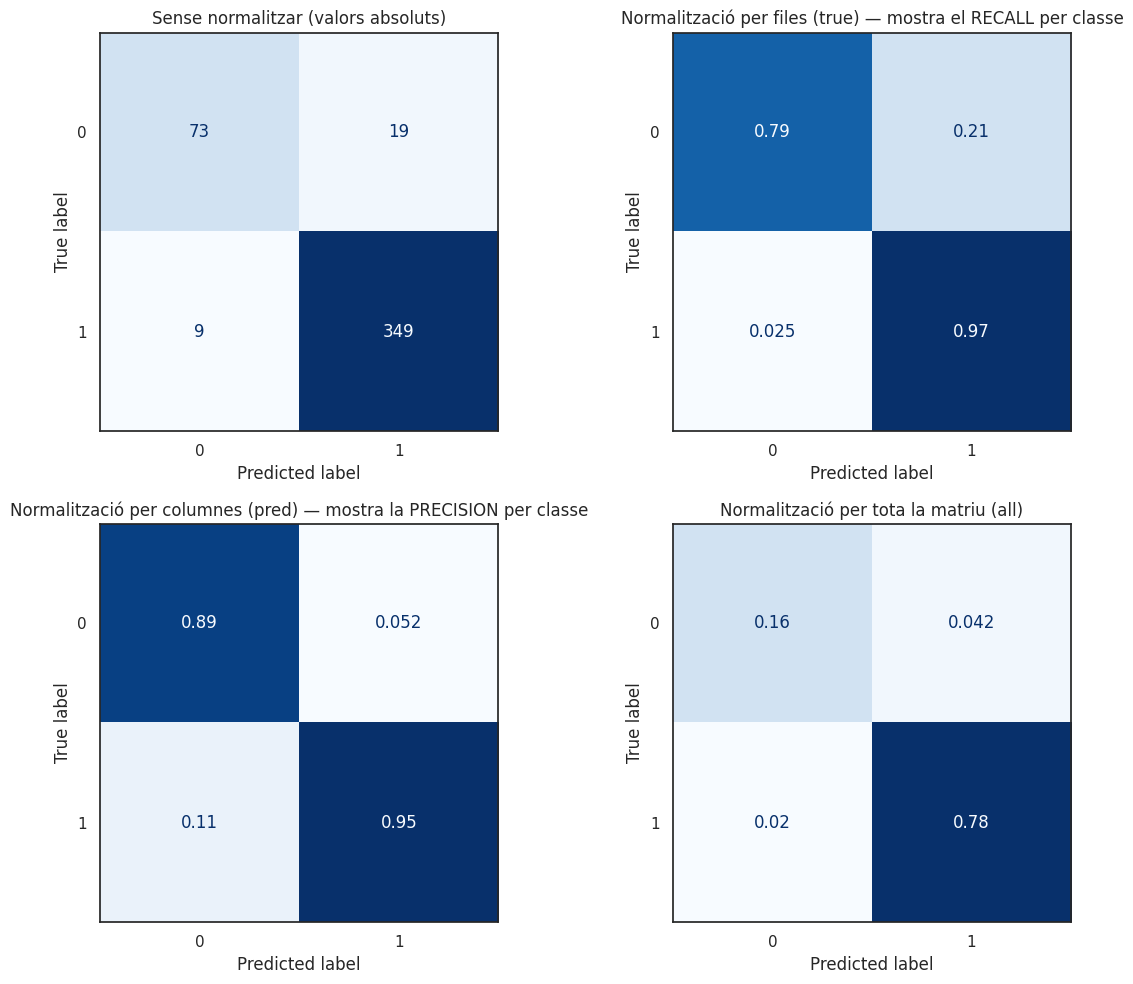

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

normalizations = [None, 'true', 'pred', 'all']
titles = [
    "Sense normalitzar (valors absoluts)",
    "Normalització per files (true) — mostra el RECALL per classe",
    "Normalització per columnes (pred) — mostra la PRECISION per classe",
    "Normalització per tota la matriu (all)"
]

for ax, norm, title in zip(axes.flatten(), normalizations, titles):
    disp = ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        normalize=norm,
        cmap="Blues",
        colorbar=False,
        ax=ax
    )
    ax.set_title(title)

plt.tight_layout()
plt.show()


### 7.Explorant l'efecte del llindar (threshold)
La regressió logística per defecte considera "positiu" si p > 0.5.
Però podem variar el llindar per veure com canvien les mètriques.

In [ ]:
thresholds = np.linspace(0.0, 1.0, 50)
precisions = []
recalls = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t))


### 8. Gràfic Precision vs Recall segons threshold

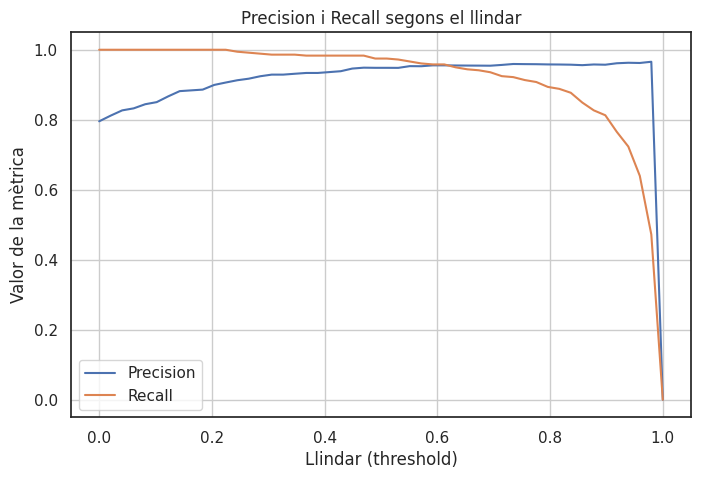

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.xlabel("Llindar (threshold)")
plt.ylabel("Valor de la mètrica")
plt.title("Precision i Recall segons el llindar")
plt.legend()
plt.grid()
plt.show()
